# Курсовая работа
## *Решение задачи мультилейбл-классификации на основе датасета CMU-MOSEI*
по курсу Глубокое обучение  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Двойникова Анастасия А.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

In [60]:
# !uv pip install pandas numpy spacy nltk num2words tqdm librosa matplotlib seaborn wordcloud

In [61]:
# !uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm.autonotebook import tqdm
tqdm.pandas()
import librosa
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
from num2words import num2words
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)

from pathlib import Path

custom_exceptions = {
    'not', 'no', 'never', 'nor', 'neither', 
    'but', 'however', 'although', 'very', 
    'too', 'extremely', 'again', 'still', 
    'only', 'just', 'against', 'up', 'down'
}
stop_words = set(stopwords.words('english')) - custom_exceptions

import spacy
nlp = spacy.load("en_core_web_sm")

pd.options.display.max_colwidth = 15
pd.options.display.max_columns = 50
pd.options.display.max_rows = 30

Path("../datasets").mkdir(parents=True, exist_ok=True)

audio_base = '../datasets/audio/'
RANDOM_STATE = 42
emotion_cols = ['happy', 'sad', 'anger', 'surprise', 'disgust', 'fear']

[nltk_data] Downloading package stopwords to /home/ext-
[nltk_data]     yankin@ad.speechpro.com/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ext-
[nltk_data]     yankin@ad.speechpro.com/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


## загрузка и осмотр датасета

In [63]:
train_df = pd.read_csv('../datasets/train.csv')
train_df.head(3)

,video,start_time,end_time,sentiment,happy,sad,anger,surprise,disgust,fear,text,ASR
0,-3g5yACwYnA,82.7645,100.5550,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.666667,Key is part...,key part o...
1,-3g5yACwYnA,119.9190,125.2990,0.666667,0.000000,0.000000,0.0,0.0,0.0,0.000000,They've bee...,is that we...
2,-3g5yACwYnA,4.8400,13.6315,0.000000,0.666667,0.666667,0.0,0.0,0.0,0.333333,Key Polymer...,creations ...


In [64]:
train_df = train_df.drop(columns=['ASR', 'sentiment'], errors='ignore')
train_df = train_df.rename(columns={'video': 'fname'})
train_df.head(3)

,fname,start_time,end_time,happy,sad,anger,surprise,disgust,fear,text
0,-3g5yACwYnA,82.7645,100.5550,0.666667,0.666667,0.0,0.0,0.0,0.666667,Key is part...
1,-3g5yACwYnA,119.9190,125.2990,0.000000,0.000000,0.0,0.0,0.0,0.000000,They've bee...
2,-3g5yACwYnA,4.8400,13.6315,0.666667,0.666667,0.0,0.0,0.0,0.333333,Key Polymer...


In [65]:
import IPython.display as ipd
fname, start_time, end_time, text = train_df.sample(1).iloc[0][['fname', 'start_time', 'end_time', 'text']]
fname += '.wav'
wav, sr = librosa.load(audio_base + fname,
                       offset=start_time,
                       duration=end_time-start_time)
print(text)
ipd.Audio(wav, rate=sr, autoplay=True)

HIGH TEMPERATURE TOMORROW WILL BE 64 DEGREES


### статистический анализ датасета

In [66]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16274 entries, 0 to 16273
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fname       16274 non-null  str    
 1   start_time  16274 non-null  float64
 2   end_time    16274 non-null  float64
 3   happy       16274 non-null  float64
 4   sad         16274 non-null  float64
 5   anger       16274 non-null  float64
 6   surprise    16274 non-null  float64
 7   disgust     16274 non-null  float64
 8   fear        16274 non-null  float64
 9   text        16274 non-null  str    
dtypes: float64(8), str(2)
memory usage: 1.2 MB


In [67]:
train_df.describe()

,start_time,end_time,happy,sad,anger,surprise,disgust,fear
count,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000
mean,62.644087,69.808617,0.486768,0.161259,0.158166,0.048943,0.124667,0.040494
std,76.860260,76.704018,0.640150,0.331518,0.367820,0.172161,0.327609,0.151935
min,0.000000,0.391000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.663550,25.125500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.712250,50.039000,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,82.025000,89.507413,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000
max,904.404943,907.045079,3.000000,3.000000,3.000000,3.000000,3.000000,1.666667


- можно немного оптимизировать использование памяти за счёт изменения типов данных;
- `столбцы эмоций`: `float64 -> float32`, тк максимальное значение 3.0;
- `столбцы времени`: `float64 -> float32`, тк максимальное значение ~997.0;

In [68]:
time_cols = ['start_time', 'end_time']

train_df[emotion_cols] = train_df[emotion_cols].astype('float32')
train_df[time_cols] = train_df[time_cols].astype('float32')

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16274 entries, 0 to 16273
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fname       16274 non-null  str    
 1   start_time  16274 non-null  float32
 2   end_time    16274 non-null  float32
 3   happy       16274 non-null  float32
 4   sad         16274 non-null  float32
 5   anger       16274 non-null  float32
 6   surprise    16274 non-null  float32
 7   disgust     16274 non-null  float32
 8   fear        16274 non-null  float32
 9   text        16274 non-null  str    
dtypes: float32(8), str(2)
memory usage: 763.0 KB


## 1. eda меток
- средняя интенсивность эмоций;
- анализ разреженности (процент абсолютных нулей для каждой эмоции);
- анализ уникальных спикеров (проверка на Speaker Leakage)
- тепловая карта корреляции эмоций.

### средняя интенсивность эмоций

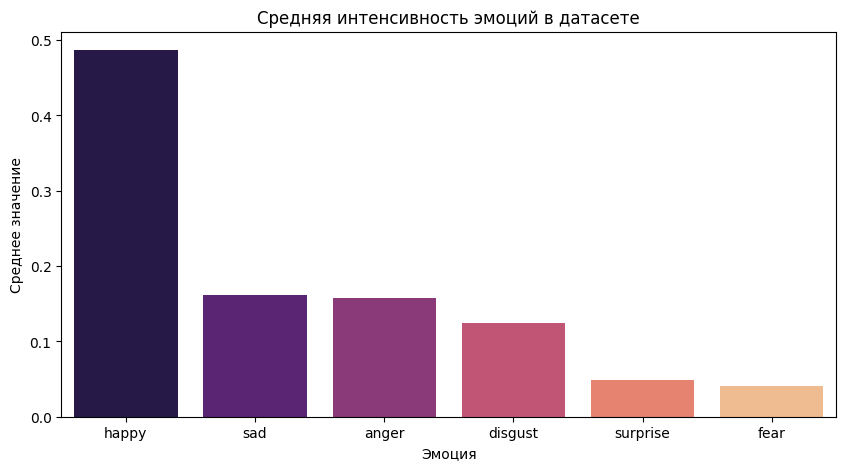

In [69]:
mean_emotions = train_df[emotion_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=mean_emotions.index, 
    y=mean_emotions.values, 
    hue=mean_emotions.index, 
    palette='magma', 
    legend=False
)
plt.title('Средняя интенсивность эмоций в датасете')
plt.ylabel('Среднее значение')
plt.xlabel('Эмоция')
plt.show()

### анализ ненулевых эмоций
- анализ разреженности
- распределение количества эмоций

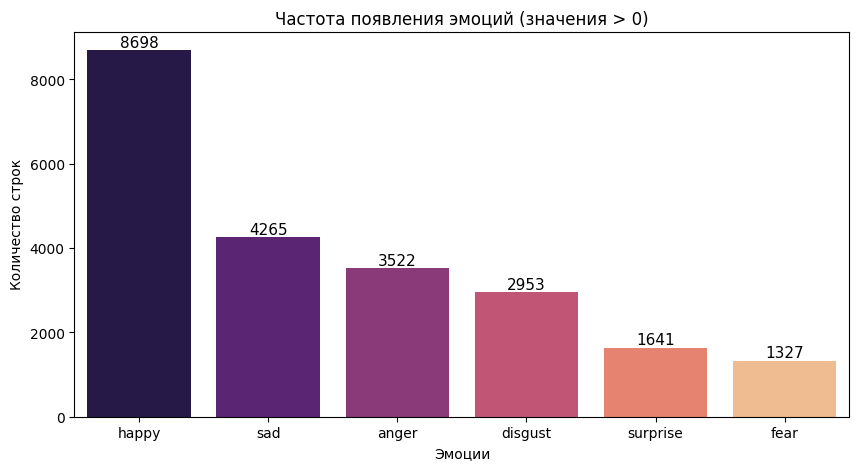

In [112]:
nonzero_counts = (train_df[emotion_cols] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=nonzero_counts.index, y=nonzero_counts.values, hue=nonzero_counts.index, palette='magma', legend=False)

for i, val in enumerate(nonzero_counts.values):
    plt.text(i, val, int(val), ha='center', va='bottom', fontsize=11)
plt.title('Частота появления эмоций (значения > 0)')
plt.ylabel('Количество строк')
plt.xlabel('Эмоции')
plt.show()

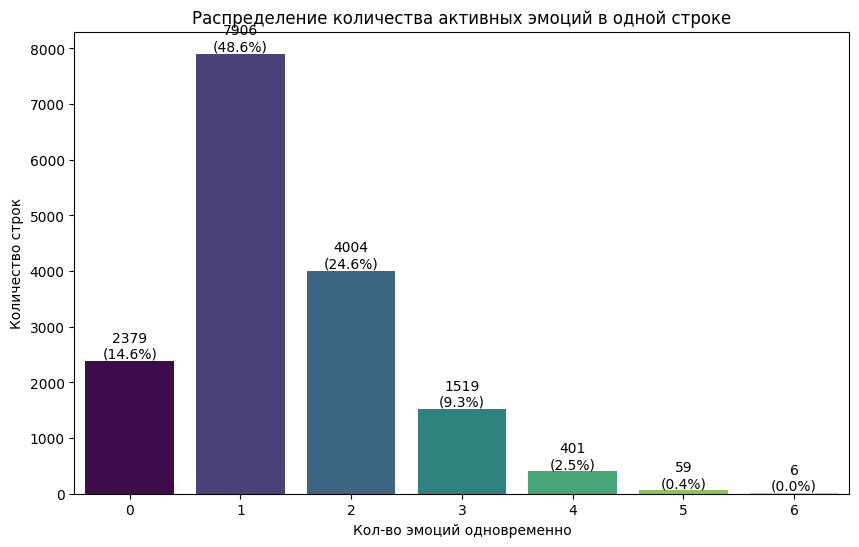

In [114]:
train_df['active_emotions_count'] = (train_df[emotion_cols] > 0).sum(axis=1)
sparsity_dist = train_df['active_emotions_count'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=sparsity_dist.index, y=sparsity_dist.values, palette='viridis', hue=sparsity_dist.index, legend=False)

for i, val in enumerate(sparsity_dist.values):
    plt.text(i, val, f"{val}\n({val/len(train_df):.1%})", ha='center', va='bottom', fontsize=10)

plt.title('Распределение количества активных эмоций в одной строке')
plt.xlabel('Кол-во эмоций одновременно')
plt.ylabel('Количество строк')
plt.show()

### тепловая карта корреляции эмоций

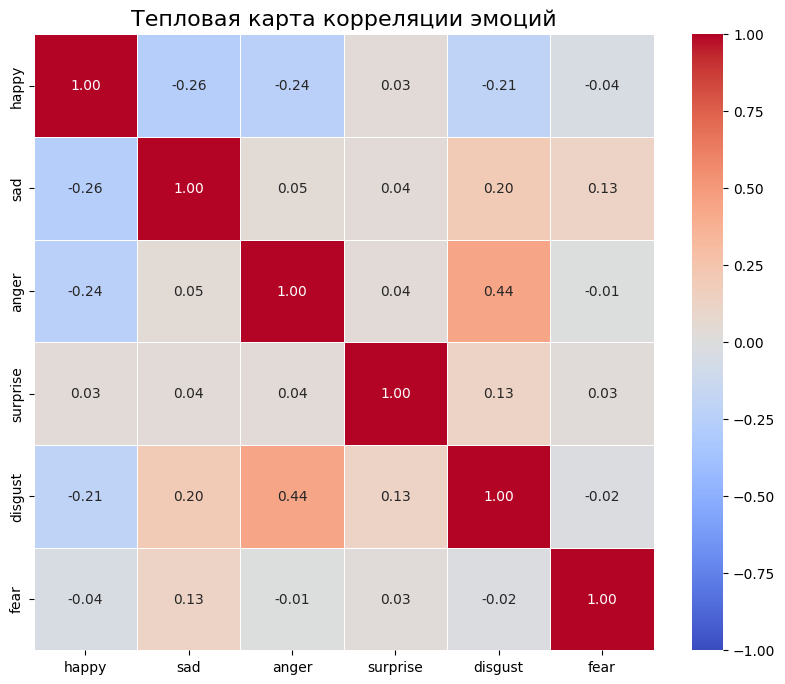

In [72]:
correlation_matrix = train_df[emotion_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Тепловая карта корреляции эмоций', fontsize=16)
plt.show()

### анализ уникальных спикеров

Количество уникальных спикеров: 2244


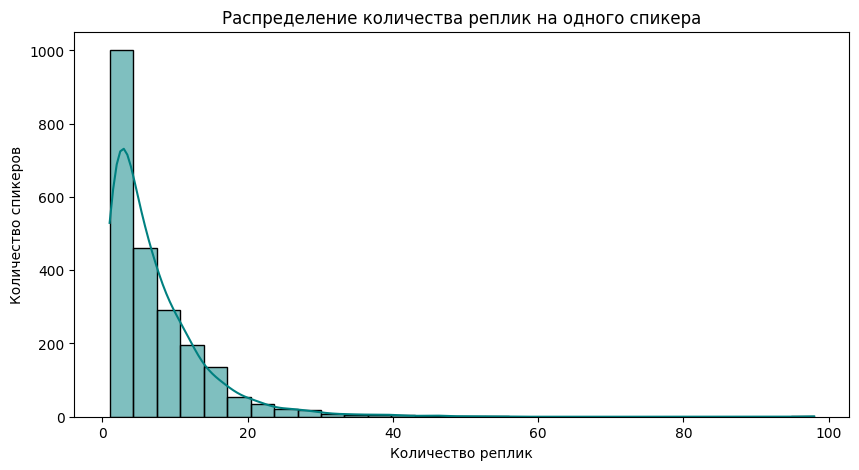

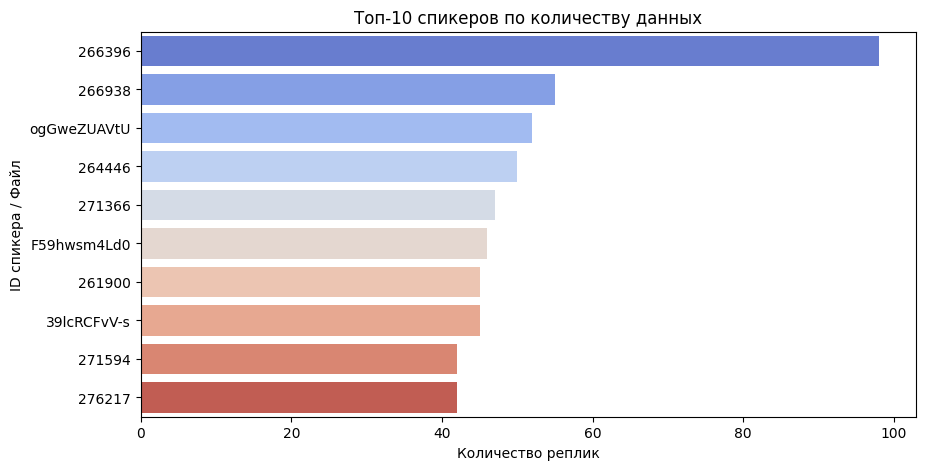

Доля самого активного спикера: 0.60%


In [73]:
unique_speakers = train_df['fname'].nunique()
print(f"Количество уникальных спикеров: {unique_speakers}")

speaker_counts = train_df['fname'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(speaker_counts, bins=30, kde=True, color='teal')
plt.title('Распределение количества реплик на одного спикера')
plt.xlabel('Количество реплик')
plt.ylabel('Количество спикеров')
plt.show()

top_speakers = speaker_counts.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_speakers.values, y=top_speakers.index, hue=top_speakers.index, palette='coolwarm', legend=False)
plt.title('Топ-10 спикеров по количеству данных')
plt.xlabel('Количество реплик')
plt.ylabel('ID спикера / Файл')
plt.show()

max_share = (speaker_counts.max() / len(train_df)) * 100
print(f"Доля самого активного спикера: {max_share:.2f}%")


## 2 eda текстовых признаков
- обработка текстов;
- корреляция эмоции от длины текста;
- анализ популярных слов;
- анализ слов-маркеров для эмоций;
- валидация через Sentiment Analysis (VADER/TextBlob).

*Если корреляция низкая, значит, эмоция выражена не словами, а интонацией. Это аргумент в пользу мультимодальности.*

### обработка текстов
- обработка чисел, лемматизация, фильтрация по англ. алфавиту, приведение к нижнему регистру, фильтрация стоп-слов
- `вход -> выход`: `(train_df['text'] : DataFrame) -> (train_df['text_clean'] : DataFrame)`

In [74]:
RE_SUFFIX = re.compile(r'\b(\d+)-[a-z]+\b')
RE_MIXED = re.compile(r'\b\d+[a-z]+\b')
RE_NUMBER = re.compile(r'\b\d+(?:\.\d+)?')

def text2num(match):
    val = match.group()
    if len(val) > 15: 
        return val
    try:
        return num2words(val, lang='en')
    except (ValueError, TypeError):
        return val

def split_mixed_numchar(match):
    word = match.group()
    num = "".join(c for c in word if c.isdigit())
    txt = "".join(c for c in word if c.isalpha())
    return f"{num2words(num, lang='ru')} {txt}".strip()

def clean_patterns(text):
    text = text.lower()
    text = RE_SUFFIX.sub(r'\1', text)
    text = RE_MIXED.sub(split_mixed_numchar, text)
    text = RE_NUMBER.sub(text2num, text)
    return text

def prepare(text):
    text = clean_patterns(text)
    doc = nlp(text)
    tokens = [
        t.lemma_.lower() for t in doc 
        if t.is_alpha and len(t) > 1 and 
        (t.text.lower() not in stop_words or t.text.lower() in custom_exceptions)
    ]
    return " ".join(tokens)

In [75]:
train_df['text_clean'] = train_df['text'].astype(str).parallel_apply(prepare)
train_df['num_tokens'] = train_df['text_clean'].str.split().apply(len)
train_df['text_clean'].head(3)

0    key part pe...
1    able find s...
2    key polymer...
Name: text_clean, dtype: str

### корреляция эмоции от длины текста

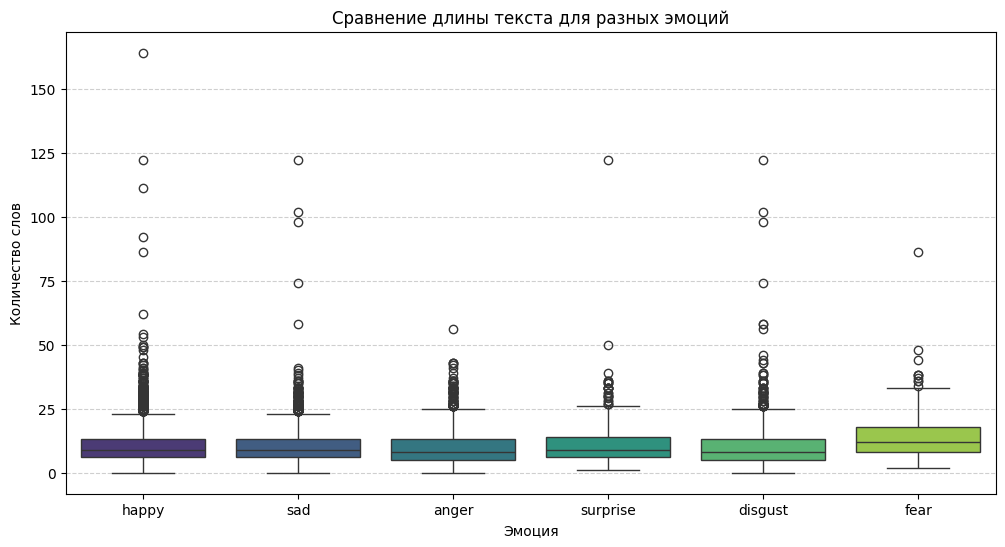

In [76]:
comparison_data = []

for emo in emotion_cols:
    threshold = 0.5
    temp_df = train_df[train_df[emo] > threshold][['num_tokens']].copy()
    temp_df['emotion_type'] = emo
    comparison_data.append(temp_df)

df_plot = pd.concat(comparison_data)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='emotion_type', y='num_tokens', hue='emotion_type', palette='viridis', legend=False)

plt.title('Сравнение длины текста для разных эмоций')
plt.xlabel('Эмоция')
plt.ylabel('Количество слов')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### анализ популярных слов

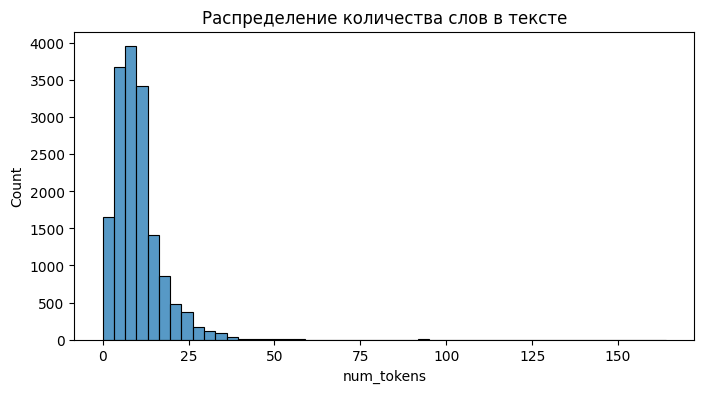

In [77]:
plt.figure(figsize=(8,4))
sns.histplot(train_df['num_tokens'], bins=50)
plt.title('Распределение количества слов в тексте')
plt.show()

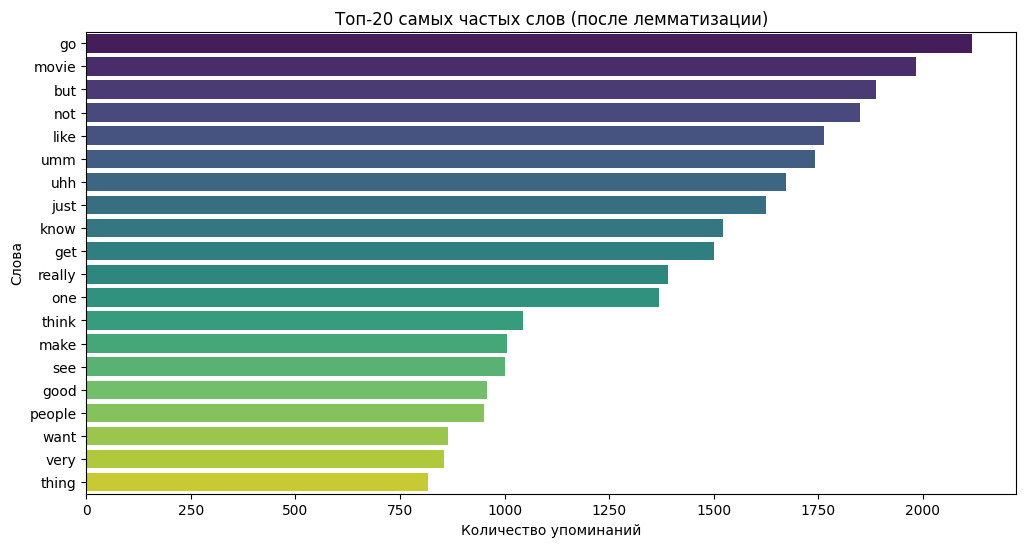

In [78]:
from collections import Counter
all_words = train_df['text_clean'].dropna().str.split().explode()
word_counts = Counter(all_words).most_common(20)
words, counts = zip(*word_counts)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(counts), 
    y=list(words), 
    hue=list(words), 
    palette='viridis', 
    legend=False
)
plt.title('Топ-20 самых частых слов (после лемматизации)')
plt.xlabel('Количество упоминаний')
plt.ylabel('Слова')
plt.show()

### анализ слов-маркеров для эмоций

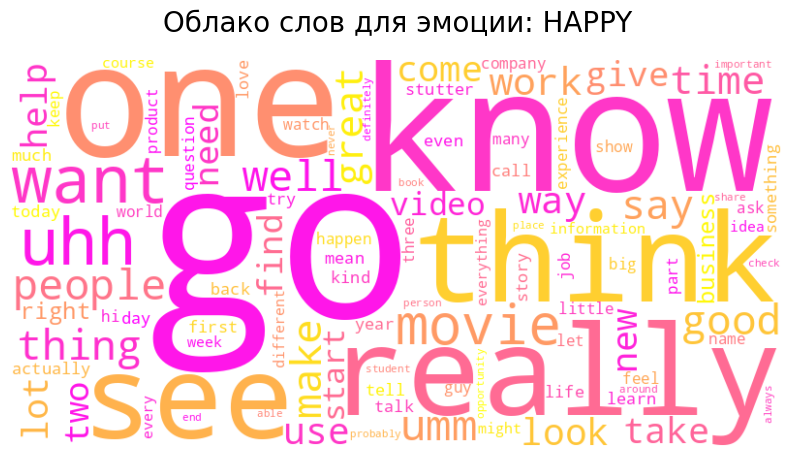


Топ-10 слов для: HAPPY
1. go — встретилось 706 раз
2. know — встретилось 462 раз
3. one — встретилось 384 раз
4. really — встретилось 368 раз
5. think — встретилось 353 раз
6. see — встретилось 330 раз
7. want — встретилось 326 раз
8. uhh — встретилось 321 раз
9. movie — встретилось 313 раз
10. people — встретилось 294 раз


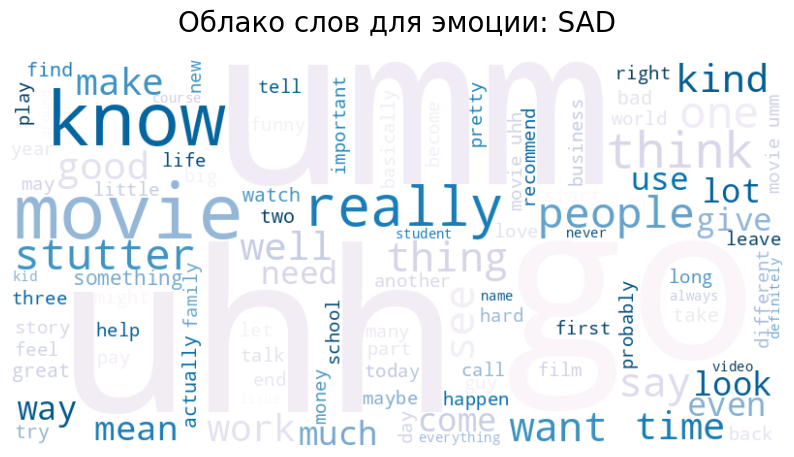


Топ-10 слов для: SAD
1. uhh — встретилось 603 раз
2. umm — встретилось 599 раз
3. go — встретилось 566 раз
4. movie — встретилось 544 раз
5. know — встретилось 517 раз
6. really — встретилось 435 раз
7. think — встретилось 346 раз
8. one — встретилось 275 раз
9. stutter — встретилось 266 раз
10. people — встретилось 262 раз


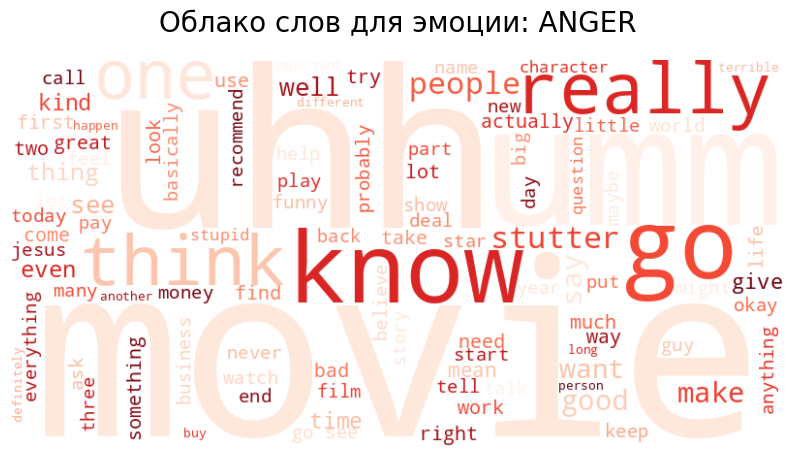


Топ-10 слов для: ANGER
1. movie — встретилось 574 раз
2. uhh — встретилось 460 раз
3. umm — встретилось 436 раз
4. know — встретилось 429 раз
5. go — встретилось 418 раз
6. really — встретилось 301 раз
7. think — встретилось 281 раз
8. one — встретилось 275 раз
9. stutter — встретилось 240 раз
10. people — встретилось 233 раз


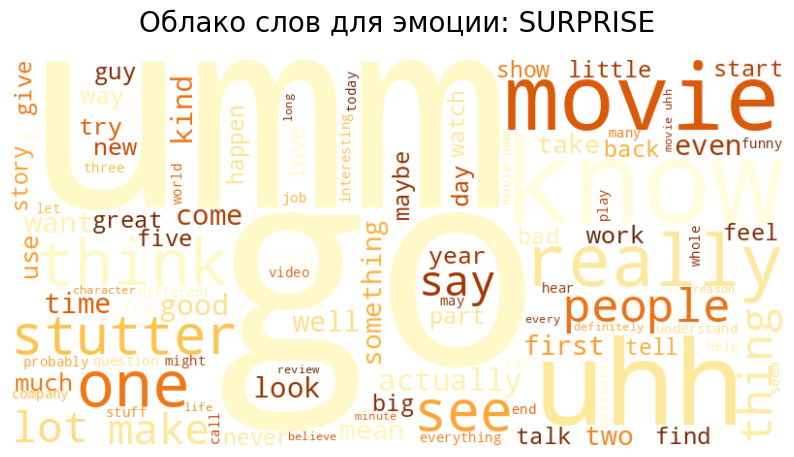


Топ-10 слов для: SURPRISE
1. go — встретилось 257 раз
2. umm — встретилось 246 раз
3. know — встретилось 226 раз
4. uhh — встретилось 226 раз
5. movie — встретилось 223 раз
6. really — встретилось 213 раз
7. think — встретилось 168 раз
8. one — встретилось 162 раз
9. see — встретилось 124 раз
10. stutter — встретилось 123 раз


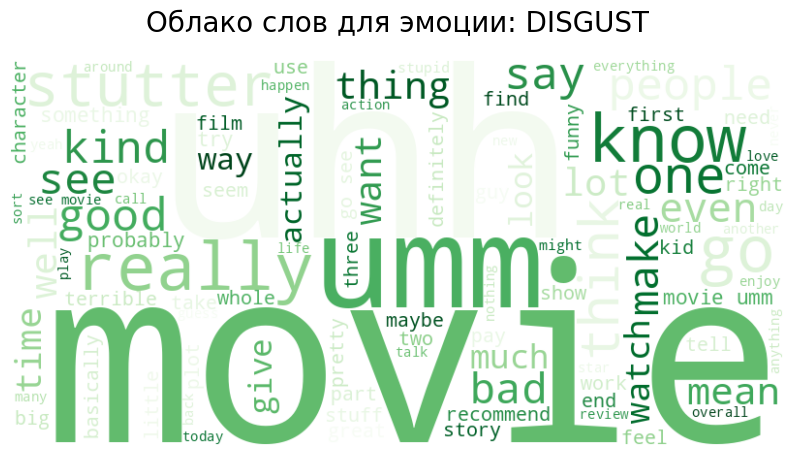


Топ-10 слов для: DISGUST
1. movie — встретилось 729 раз
2. uhh — встретилось 642 раз
3. umm — встретилось 567 раз
4. really — встретилось 416 раз
5. know — встретилось 412 раз
6. go — встретилось 390 раз
7. stutter — встретилось 344 раз
8. think — встретилось 275 раз
9. one — встретилось 246 раз
10. say — встретилось 191 раз


In [79]:
from wordcloud import WordCloud

emotions = ['happy', 'sad', 'anger', 'surprise', 'disgust']
colors = {'happy': 'spring', 'sad': 'PuBu', 'anger': 'Reds', 
          'surprise': 'YlOrBr', 'disgust': 'Greens'}

for emo in emotions:
    threshold = train_df[emo].mean()
    subset = train_df[train_df[emo] > threshold]['text_clean'].dropna()
    text_combined = " ".join(subset.astype(str))
    
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        colormap=colors.get(emo, 'viridis'),
        max_words=100,
        random_state=42
    ).generate(text_combined)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Облако слов для эмоции: {emo.upper()}', fontsize=20, pad=20)
    plt.axis('off')
    plt.show()

    word_freq = wc.process_text(text_combined)
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

    print(f"\nТоп-10 слов для: {emo.upper()}")
    for i, (word, freq) in enumerate(sorted_words[:10], 1):
        print(f"{i}. {word} — встретилось {freq} раз")

### валидация через Sentiment Analysis

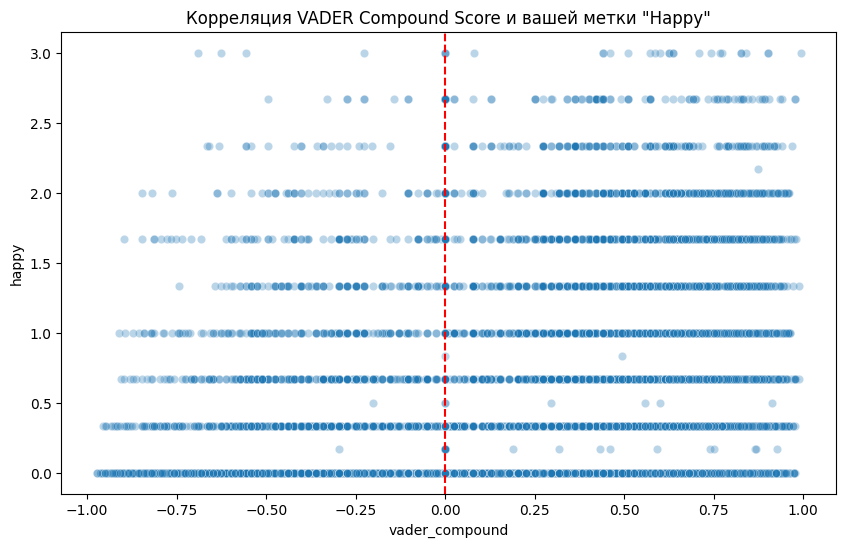

Корреляция эмоций с общим сентиментом VADER:
happy       0.204334
fear        0.015638
surprise   -0.024006
sad        -0.111737
anger      -0.155865
disgust    -0.174980
dtype: float64


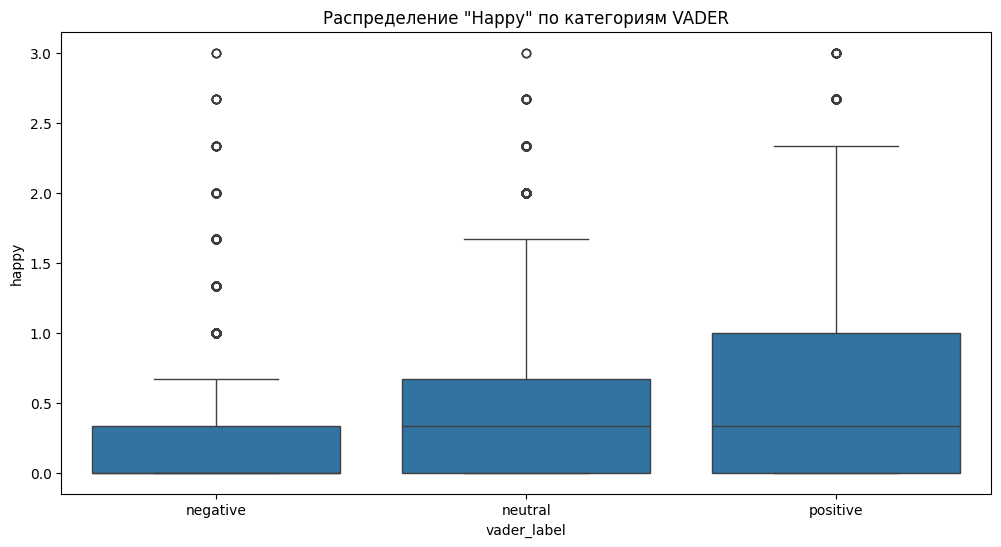

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

vader_scores = train_df['text_clean'].apply(lambda x: analyzer.polarity_scores(x))
vader_compound = vader_scores.apply(lambda x: x['compound'])
vader_label = vader_compound.apply(lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral'))

plt.figure(figsize=(10, 6))
sns.scatterplot(x=vader_compound, y=train_df['happy'], alpha=0.3)
plt.title('Корреляция VADER Compound Score и вашей метки "Happy"')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('vader_compound')
plt.ylabel('happy')
plt.show()

correlations = train_df[emotion_cols].corrwith(vader_compound)
print("Корреляция эмоций с общим сентиментом VADER:")
print(correlations.sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.boxplot(x=vader_label, y=train_df['happy'], order=['negative', 'neutral', 'positive'])
plt.title('Распределение "Happy" по категориям VADER')
plt.xlabel('vader_label')
plt.ylabel('happy')
plt.show()

## 3 eda аудио-признаков
- формирование метаинформации аудио;
- просодический анализ (Извлечь F0 (Pitch) и Energy для сегментов. Построить Scatter plots: «Средний Pitch vs Anger» или «Energy vs Happy»);
- анализ пауз и темпа речи (Рассчитать отношение длительности слов к длительности пауз (Ratio of silence).);
- спектральный анализ аудио по классам эмоций (Взять по 50 самых ярких примеров каждой эмоции, рассчитать их Мел-спектрограммы и усреднить их в одну картинку для каждой эмоции.);

### метаинформация аудио
- `вход -> выход`: `(train_df['fname'] : DataFrame) -> (train_df[['duration', 'sr', 'rms', 'zcr']])`

In [ ]:
def get_audio_info(row):
    path = audio_base + row['fname'] + '.wav'
    start = row['start_time']
    dur = row['end_time'] - start
    
    y, sr = librosa.load(path, offset=start, duration=dur)
    
    return pd.Series({
        'duration': librosa.get_duration(y=y, sr=sr),
        'rms': np.mean(librosa.feature.rms(y=y)),
        'zcr': np.mean(librosa.feature.zero_crossing_rate(y=y))
    })

audio_features = train_df.parallel_apply(get_audio_info, axis=1)
train_df = pd.concat([train_df, audio_features], axis=1)

In [82]:
audio_features.describe()

,duration,rms,zcr
count,16274.000000,16274.000000,16274.000000
mean,7.162140,0.055185,0.098857
std,5.059115,0.041020,0.034405
min,0.189478,0.000000,0.000000
25%,3.904535,0.026229,0.075714
50%,6.019002,0.044803,0.095917
75%,9.074512,0.073066,0.119200
max,108.928571,0.336952,0.408279


### просодический анализ
- длина аудио ~ эмоция
- громкость аудио ~ эмоция
- частота (форманты/тембр/гармоники) ~ эмоция

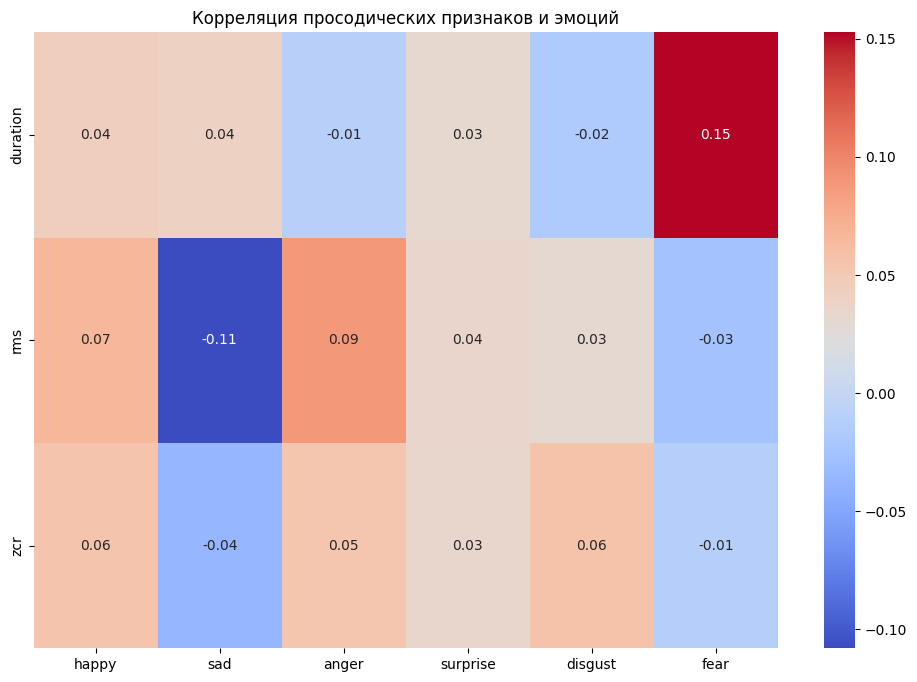

In [83]:
# аудио-фичи vs эмоции
audio_cols = ['duration', 'rms', 'zcr']
corr_matrix = train_df[audio_cols + emotion_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix.loc[audio_cols, emotion_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция просодических признаков и эмоций')
plt.show()

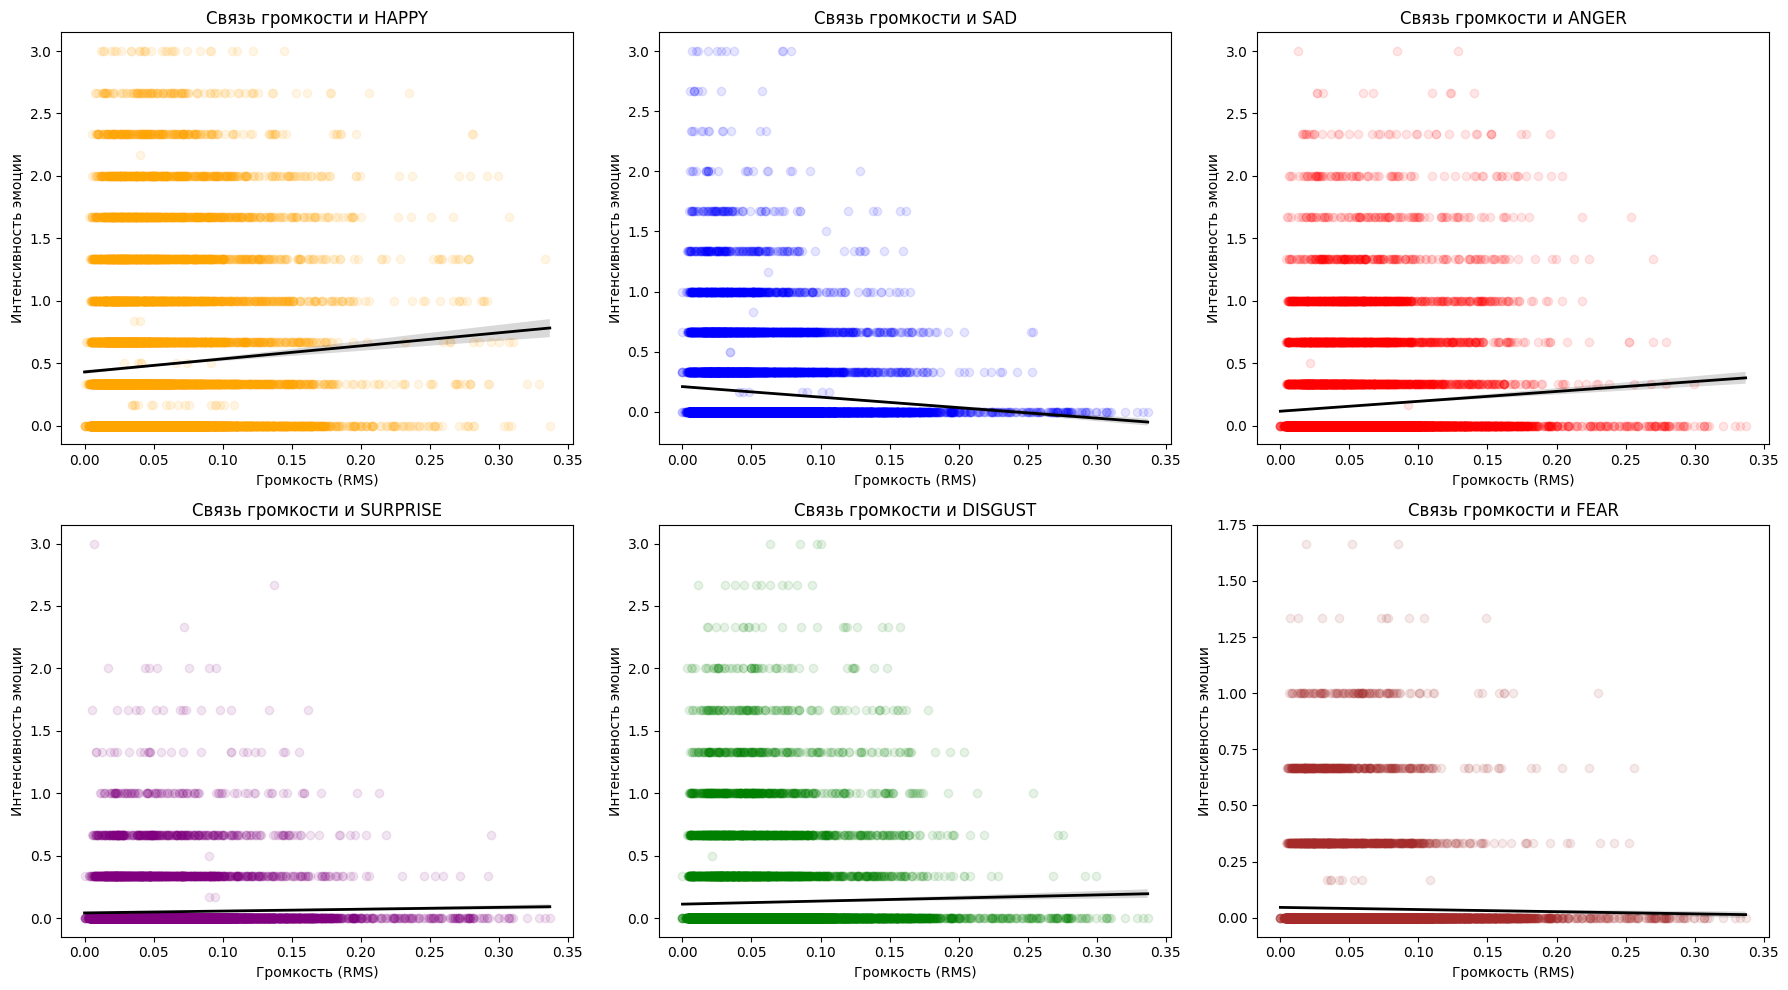

In [86]:
# громкость (rms) vs эмоции
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['orange', 'blue', 'red', 'purple', 'green', 'brown']

for i, (emotion, color) in enumerate(zip(emotion_cols, colors)):
    sns.regplot(
        data=train_df, 
        x='rms', 
        y=emotion, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.1, 'color': color}, 
        line_kws={'color': 'black', 'linewidth': 2}
    )
    axes[i].set_title(f'Связь громкости и {emotion.upper()}')
    axes[i].set_xlabel('Громкость (RMS)')
    axes[i].set_ylabel('Интенсивность эмоции')

plt.tight_layout()
plt.show()

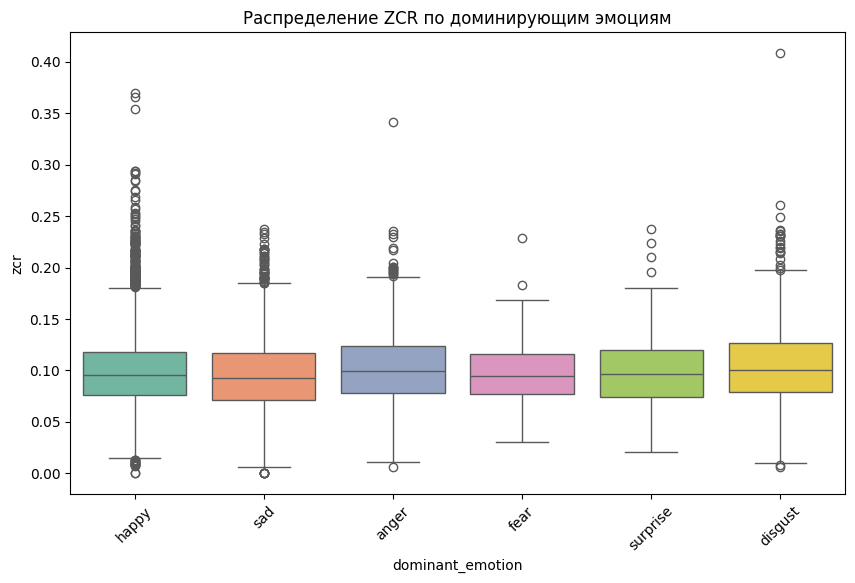

In [87]:
# анализ тембра/частоты (zcr)
plt.figure(figsize=(10, 6))
train_df['dominant_emotion'] = train_df[emotion_cols].idxmax(axis=1)
sns.boxplot(x='dominant_emotion', y='zcr', data=train_df, hue='dominant_emotion', legend=False, palette='Set2')
plt.title('Распределение ZCR по доминирующим эмоциям')
plt.xticks(rotation=45)
plt.show()

### анализ пауз и темпа речи

In [89]:
window_ms = 25
step_ms = 10
n_fft = 2048
n_mfcc = 13

In [98]:
window_ms = 25
step_ms = 10
n_fft = 512
n_mfcc = 20

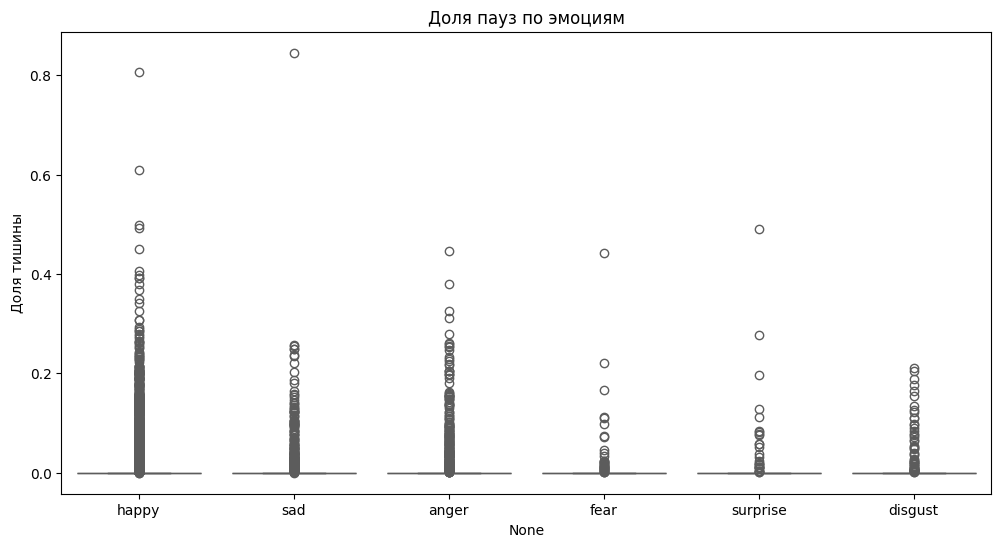

In [104]:
def analyze_pauses_vad(row):
    path = audio_base + row['fname'] + '.wav'
    start_time = row['start_time']
    duration = row['end_time']-row['start_time']

    y, sr = librosa.load(path, offset=start_time, duration=duration)
    y = librosa.effects.preemphasis(y)

    hop_length = step_ms * sr // 1000
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop_length)
    db_rms = librosa.amplitude_to_db(rms, ref=np.max)
    rms = np.mean(rms)
    threshold = librosa.amplitude_to_db(np.array([rms]))[0] - 20
    
    is_speech = (db_rms > threshold).astype(float)
    speech_ratio = np.mean(is_speech)
    pause_ratio = 1.0 - speech_ratio
    
    return pd.Series({
        'vad_pause_ratio': pause_ratio,
        'vad_speech_ratio': speech_ratio
    })

vad_features = train_df.parallel_apply(analyze_pauses_vad, axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(
    x=train_df[emotion_cols].idxmax(axis=1), 
    y=vad_features['vad_pause_ratio'], 
    hue=train_df[emotion_cols].idxmax(axis=1), 
    palette='coolwarm', 
    legend=False
)
plt.title('Доля пауз по эмоциям')
plt.ylabel('Доля тишины')
plt.show()

### спектральный анализ аудио по классам эмоций

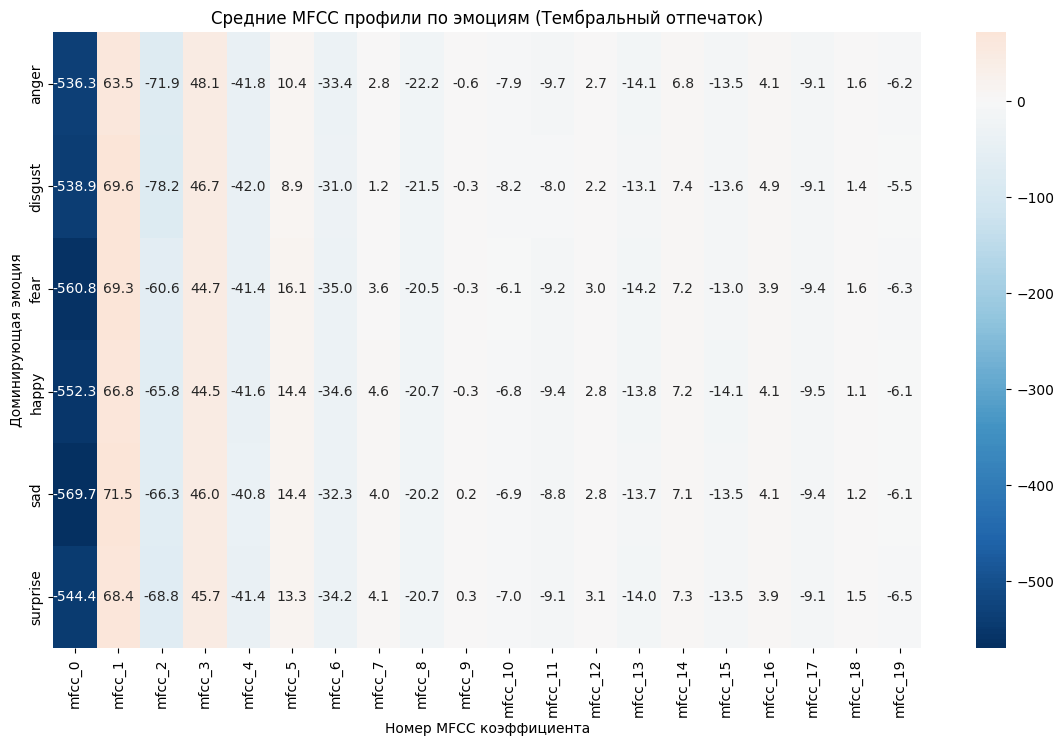

In [110]:
def get_mfcc(row):
    path = audio_base + row['fname'] + '.wav'
    start_time = row['start_time']
    duration = row['end_time']-row['start_time']
    
    y, sr = librosa.load(path, offset=start_time, duration=duration)
    y = librosa.effects.preemphasis(y)
    
    hop_length = step_ms * sr // 1000
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc_mean = np.mean(mfccs, axis=1)
    
    res = {f'mfcc_{i}': val for i, val in enumerate(mfcc_mean)}
    res['dominant_emotion'] = row[emotion_cols].astype(float).idxmax()
    return pd.Series(res)

mfcc_features = train_df.parallel_apply(get_mfcc, axis=1)

mfcc_avg = mfcc_features.groupby('dominant_emotion')[[f'mfcc_{i}' for i in range(n_mfcc)]].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(mfcc_avg, annot=True, fmt=".1f", cmap='RdBu_r', center=0)
plt.title('Средние MFCC профили по эмоциям (Тембральный отпечаток)')
plt.ylabel('Доминирующая эмоция')
plt.xlabel('Номер MFCC коэффициента')
plt.show()

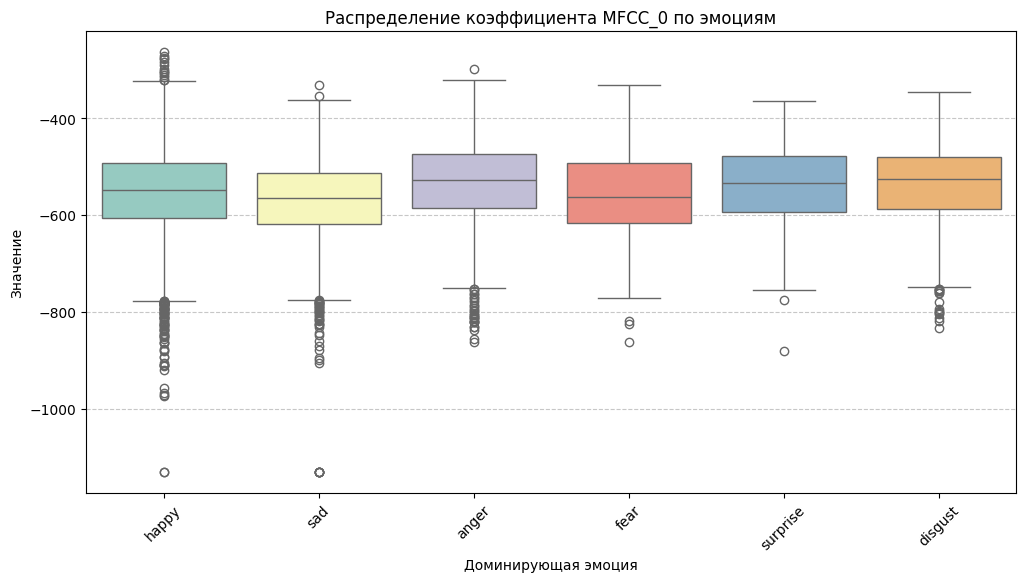

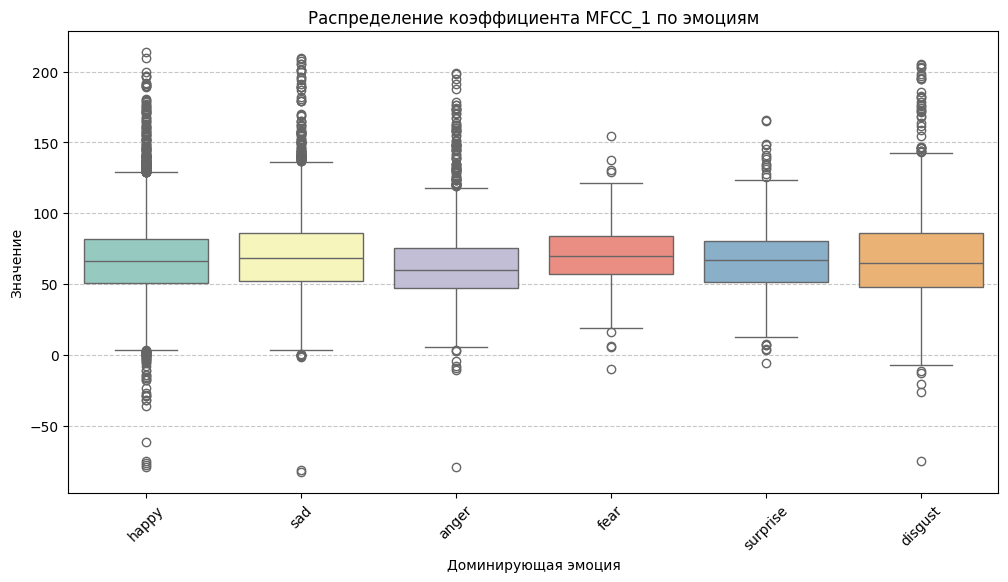

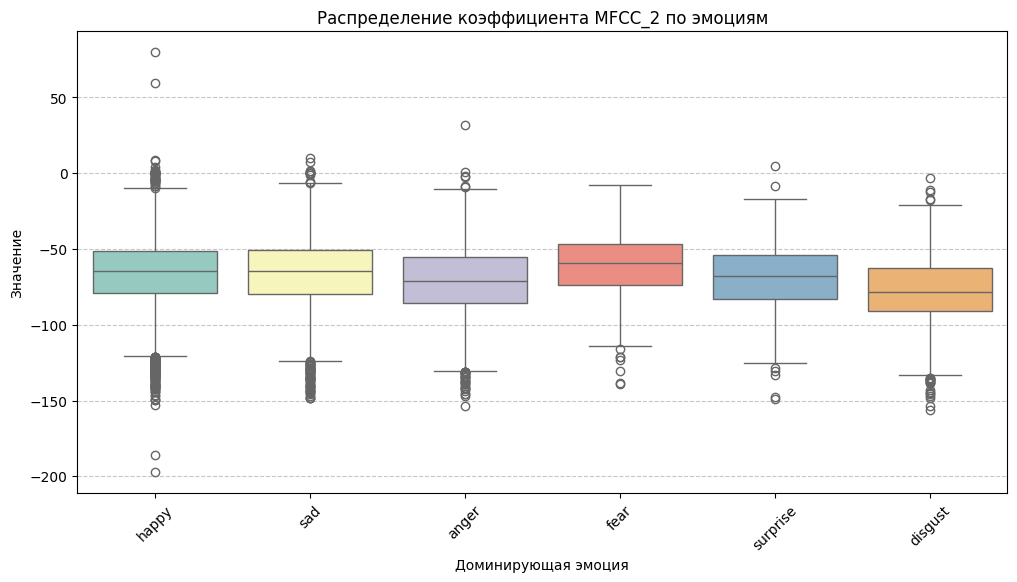

In [111]:
for i in range(0, 3):
    name = f'mfcc_{i}'
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=mfcc_features, 
        x='dominant_emotion', 
        y=name, 
        hue='dominant_emotion', 
        palette='Set3', 
        legend=False
    )
    
    plt.title(f'Распределение коэффициента {name.upper()} по эмоциям')
    plt.xlabel('Доминирующая эмоция')
    plt.ylabel('Значение')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()